In [50]:
import jax.numpy as jnp
from jax import grad, jit, vmap
from jax import random
from jax.scipy.special import logsumexp

key = random.PRNGKey(968234)

In [51]:
from matplotlib import pyplot as plt

In [75]:
def sigmoid(x):
    return 0.5 * (jnp.tanh(x / 2) + 1)

# Outputs probability of a label being true.
def predict(Ws, bs, xs):
    W0, W1, W2 = Ws
    b0, b1, b2 = bs
    
    layer1 = sigmoid(jnp.dot(xs, W0) + b0)
    layer2 = sigmoid(jnp.dot(layer1, W1) + b1)
    output = jnp.dot(layer2, W2) + b2
    return output.reshape(xs.shape[0])


def d_predict(Ws, bs, xs):
    to_differentiate = lambda x: predict(Ws, bs, x)[0]
    return vmap(grad(to_differentiate))(xs)


def d2_predict(Ws, bs, xs):
    to_differentiate1 = lambda x: predict(Ws, bs, x)[0]
    to_differentiate2 = lambda x: grad(to_differentiate1)(x)[0]
    return vmap(grad(to_differentiate2))(xs)


# Initialize random model coefficients
key, W_key, b_key = random.split(key, 3)
W0 = random.normal(W_key, (1,100))
b0 = random.normal(b_key, (100,))

key, W_key, b_key = random.split(key, 3)
W1 = random.normal(W_key, (100,100))
b1 = random.normal(b_key, (100,))

key, W_key, b_key = random.split(key, 3)
W2 = random.normal(W_key, (100,1))
b2 = random.normal(b_key, (1,))

Ws = (W0, W1, W2)
bs = (b0, b1, b2)

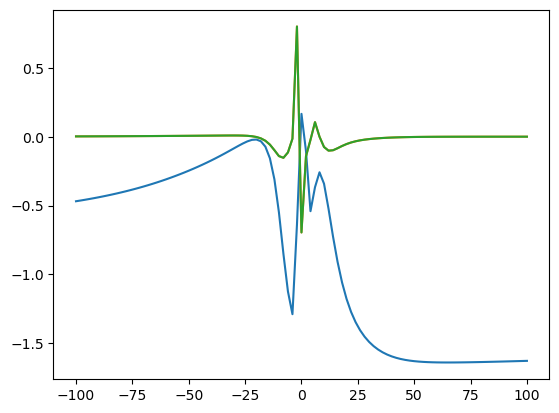

In [78]:
xs = jnp.linspace(-100, 100, 101).reshape(101, 1)
psi = predict(Ws, bs, xs)
d_psi = d_predict(Ws, bs, xs)
d2_psi = d_predict(Ws, bs, xs)
plt.plot(xs, psi)
plt.plot(xs, d_psi)
plt.plot(xs, d2_psi)

In [72]:
def cost_function(omega, W0, W1, W2, b0, b1, b2, t):
    

Array([3.1008873e-05], dtype=float32)